In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import shuffle

RANDOM_STATE = 42

In [4]:
df = load_digits()
x = df.images
y = df.target

x.shape

(1797, 8, 8)

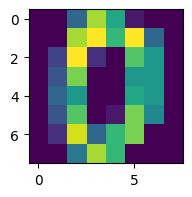

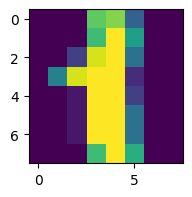

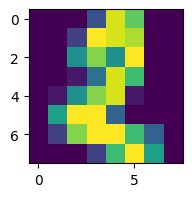

In [7]:
for i in range(3):
    plt.figure(figsize=(2,2))
    plt.imshow(x[i])

Каждая картинка - матрица чисел. Надо преобразовать каждое фото в вектор

In [9]:
x = x.reshape(x.shape[0],-1)

Перемешаем данные, потому что в исходном датасете они идут по порядку

In [11]:
x, y = shuffle(x,y)
print(x.shape, y.shape)
print(y[:10])

(1797, 64) (1797,)
[3 8 6 4 8 8 6 3 3 1]


In [12]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size=0.3, random_state=RANDOM_STATE)

In [13]:
knc = KNeighborsClassifier(n_neighbors=10)
knc.fit(xtrain,ytrain)
pred = knc.predict(xtest)

In [14]:
from sklearn.metrics import accuracy_score
print(accuracy_score(ytest, pred))

0.987037037037037


Посмотрим, как число соседей влияет на качество модели

In [ ]:
for i in range(3,20,3):
    knc = KNeighborsClassifier(n_neighbors=i)
    knc.fit(xtrain, ytrain)
    pred = knc.predict(xtest)
    print(f'neighbors: {i}')
    print(f'accuracy = {accuracy_score(ytest, pred)}')

neighboors: 3
accuracy = 0.9851851851851852
neighboors: 6
accuracy = 0.9851851851851852
neighboors: 9
accuracy = 0.987037037037037
neighboors: 12
accuracy = 0.9814814814814815
neighboors: 15
accuracy = 0.9814814814814815
neighboors: 18
accuracy = 0.9796296296296296


Посмотрим, как влияет на качество способ учесть веса у соседей

In [19]:
for i in ['uniform','distance']:
    knc = KNeighborsClassifier(n_neighbors=9, weights=i)
    knc.fit(xtrain, ytrain)
    pred = knc.predict(xtest)
    print(f'wight: {i}')
    print(f'accuracy = {accuracy_score(ytest, pred)}')

wight: uniform
accuracy = 0.987037037037037
wight: distance
accuracy = 0.987037037037037


preducted label: 7


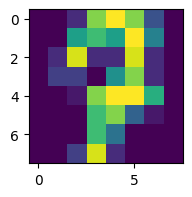

preducted label: 9


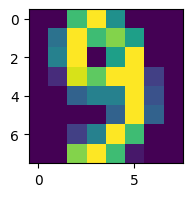

preducted label: 2


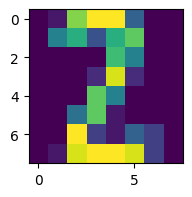

preducted label: 3


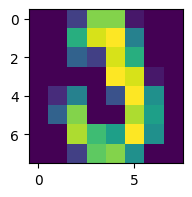

preducted label: 9


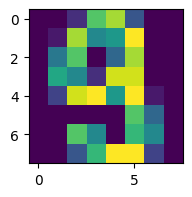

In [20]:
for i in range(5):
    print(f'preducted label: {pred[i]}')
    plt.figure(figsize=(2,2))
    plt.imshow(xtest[i].reshape((8,8)))
    plt.show()